In [ ]:
import os, sys, subprocess, importlib, pathlib

SENTINEL = "/tmp/diffrax_colab_ready_v3"

def _run(cmd):
    subprocess.check_call(cmd)

def _need_install():
    try:
        import numpy
        import jax
        import diffrax
        import equinox
        import optax
        import matplotlib
        return False
    except Exception:
        return True

if not os.path.exists(SENTINEL) or _need_install():
    _run([sys.executable, "-m", "pip", "uninstall", "-y", "numpy", "jax", "jaxlib", "diffrax", "equinox", "optax"])
    _run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip"])
    _run([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy==1.26.4",
        "jax[cpu]==0.4.38",
        "jaxlib==0.4.38",
        "diffrax",
        "equinox",
        "optax",
        "matplotlib"
    ])
    pathlib.Path(SENTINEL).write_text("ready")
    print("Packages installed cleanly. Runtime will restart now. After reconnect, run this same cell again.")
    os._exit(0)

import time
import math
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import equinox as eqx
import optax
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("JAX:", jax.__version__)
print("Backend:", jax.default_backend())

def logistic(t, y, args):
    r, k = args
    return r * y * (1 - y / k)

t0, t1 = 0.0, 10.0
ts = jnp.linspace(t0, t1, 300)
y0 = jnp.array(0.4)
args = (2.0, 5.0)

sol_logistic = diffrax.diffeqsolve(
    diffrax.ODETerm(logistic),
    diffrax.Tsit5(),
    t0=t0,
    t1=t1,
    dt0=0.05,
    y0=y0,
    args=args,
    saveat=diffrax.SaveAt(ts=ts, dense=True),
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8),
    max_steps=100000,
)

query_ts = jnp.array([0.7, 2.35, 4.8, 9.2])
query_ys = jax.vmap(sol_logistic.evaluate)(query_ts)

print("\n=== Example 1: Logistic growth ===")
print("Saved solution shape:", sol_logistic.ys.shape)
print("Interpolated values:")
for t_, y_ in zip(query_ts, query_ys):
    print(f"t={float(t_):.3f} -> y={float(y_):.6f}")

def lotka_volterra(t, y, args):
    alpha, beta, delta, gamma = args
    prey, predator = y
    dprey = alpha * prey - beta * prey * predator
    dpred = delta * prey * predator - gamma * predator
    return jnp.array([dprey, dpred])

lv_y0 = jnp.array([10.0, 2.0])
lv_args = (1.5, 1.0, 0.75, 1.0)
lv_ts = jnp.linspace(0.0, 15.0, 500)

sol_lv = diffrax.diffeqsolve(
    diffrax.ODETerm(lotka_volterra),
    diffrax.Dopri5(),
    t0=0.0,
    t1=15.0,
    dt0=0.02,
    y0=lv_y0,
    args=lv_args,
    saveat=diffrax.SaveAt(ts=lv_ts),
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8),
    max_steps=100000,
)

print("\n=== Example 2: Lotka-Volterra ===")
print("Shape:", sol_lv.ys.shape)

In [ ]:
def spring_mass_damper(t, state, args):
    k, c, m = args["k"], args["c"], args["m"]
    x = state["x"]
    v = state["v"]
    dx = v
    dv = -(k / m) * x - (c / m) * v
    return {"x": dx, "v": dv}

pytree_state0 = {"x": jnp.array([2.0]), "v": jnp.array([0.0])}
pytree_args = {"k": 6.0, "c": 0.6, "m": 1.5}
pytree_ts = jnp.linspace(0.0, 12.0, 400)

sol_pytree = diffrax.diffeqsolve(
    diffrax.ODETerm(spring_mass_damper),
    diffrax.Tsit5(),
    t0=0.0,
    t1=12.0,
    dt0=0.02,
    y0=pytree_state0,
    args=pytree_args,
    saveat=diffrax.SaveAt(ts=pytree_ts),
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8),
    max_steps=100000,
)

print("\n=== Example 3: PyTree state ===")
print("x shape:", sol_pytree.ys["x"].shape)
print("v shape:", sol_pytree.ys["v"].shape)

def damped_oscillator(t, y, args):
    omega, zeta = args
    x, v = y
    dx = v
    dv = -(omega ** 2) * x - 2.0 * zeta * omega * v
    return jnp.array([dx, dv])

batch_y0 = jnp.array([
    [1.0, 0.0],
    [1.5, 0.0],
    [2.0, 0.0],
    [2.5, 0.0],
    [3.0, 0.0],
])
batch_args = (2.5, 0.15)
batch_ts = jnp.linspace(0.0, 10.0, 300)

def solve_single(y0_single):
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(damped_oscillator),
        diffrax.Tsit5(),
        t0=0.0,
        t1=10.0,
        dt0=0.02,
        y0=y0_single,
        args=batch_args,
        saveat=diffrax.SaveAt(ts=batch_ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-7),
        max_steps=100000,
    )
    return sol.ys

batched_ys = jax.vmap(solve_single)(batch_y0)

print("\n=== Example 4: Batched solves ===")
print("Batched shape:", batched_ys.shape)

In [ ]:
sigma = 0.30
theta = 1.20
mu = 1.50
sde_ts = jnp.linspace(0.0, 6.0, 400)

def ou_drift(t, y, args):
    theta_, mu_ = args
    return theta_ * (mu_ - y)

def ou_diffusion(t, y, args):
    return jnp.array([[sigma]])

def solve_ou(key):
    bm = diffrax.VirtualBrownianTree(
        t0=0.0,
        t1=6.0,
        tol=1e-3,
        shape=(1,),
        key=key,
    )
    terms = diffrax.MultiTerm(
        diffrax.ODETerm(ou_drift),
        diffrax.ControlTerm(ou_diffusion, bm),
    )
    sol = diffrax.diffeqsolve(
        terms,
        diffrax.EulerHeun(),
        t0=0.0,
        t1=6.0,
        dt0=0.01,
        y0=jnp.array([0.0]),
        args=(theta, mu),
        saveat=diffrax.SaveAt(ts=sde_ts),
        max_steps=100000,
    )
    return sol.ys[:, 0]

sde_keys = jr.split(jr.PRNGKey(0), 5)
sde_paths = jax.vmap(solve_ou)(sde_keys)

print("\n=== Example 5: SDE ===")
print("SDE paths shape:", sde_paths.shape)

true_a = 0.25
true_b = 2.20
train_ts = jnp.linspace(0.0, 6.0, 120)

def true_dynamics(t, y, args):
    x, v = y
    dx = v
    dv = -true_b * x - true_a * v + 0.1 * jnp.sin(2.0 * t)
    return jnp.array([dx, dv])

true_sol = diffrax.diffeqsolve(
    diffrax.ODETerm(true_dynamics),
    diffrax.Tsit5(),
    t0=0.0,
    t1=6.0,
    dt0=0.01,
    y0=jnp.array([1.0, 0.0]),
    saveat=diffrax.SaveAt(ts=train_ts),
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8),
    max_steps=100000,
)

noise_key = jr.PRNGKey(42)
train_y = true_sol.ys + 0.01 * jr.normal(noise_key, true_sol.ys.shape)

In [ ]:
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key, width=64, depth=2):
        self.mlp = eqx.nn.MLP(
            in_size=3,
            out_size=2,
            width_size=width,
            depth=depth,
            activation=jax.nn.tanh,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, t, y, args):
        inp = jnp.concatenate([y, jnp.array([t])], axis=0)
        return self.mlp(inp)

class NeuralODE(eqx.Module):
    func: ODEFunc

    def __init__(self, key):
        self.func = ODEFunc(key)

    def __call__(self, ts, y0):
        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=0.01,
            y0=y0,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
            max_steps=100000,
        )
        return sol.ys

model = NeuralODE(jr.PRNGKey(123))
optim = optax.adam(1e-2)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

@eqx.filter_value_and_grad
def loss_fn(model, ts, y0, target):
    pred = model(ts, y0)
    return jnp.mean((pred - target) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, ts, y0, target):
    loss, grads = loss_fn(model, ts, y0, target)
    updates, opt_state = optim.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

print("\n=== Example 6: Neural ODE training ===")
losses = []
start = time.time()

for step in range(200):
    model, opt_state, loss = train_step(model, opt_state, train_ts, jnp.array([1.0, 0.0]), train_y)
    losses.append(float(loss))
    if step % 40 == 0 or step == 199:
        print(f"step={step:03d} loss={float(loss):.8f}")

elapsed = time.time() - start
pred_y = model(train_ts, jnp.array([1.0, 0.0]))
print(f"Training time: {elapsed:.2f}s")

jit_solver = jax.jit(solve_single)
_ = jit_solver(batch_y0[0]).block_until_ready()
bench_start = time.time()
_ = jit_solver(batch_y0[0]).block_until_ready()
bench_end = time.time()
print("\n=== Example 7: JIT benchmark ===")
print(f"Single compiled solve latency: {(bench_end - bench_start) * 1000:.2f} ms")

NumPy: 1.26.4
JAX: 0.4.38
Backend: cpu

=== Example 1: Logistic growth ===
Saved solution shape: (300,)
Interpolated values:
t=0.700 -> y=1.303487
t=2.350 -> y=4.526543
t=4.800 -> y=4.996108
t=9.200 -> y=5.000001

=== Example 2: Lotka-Volterra ===
Shape: (500, 2)

=== Example 3: PyTree state ===
x shape: (400, 1)
v shape: (400, 1)

=== Example 4: Batched solves ===
Batched shape: (5, 300, 2)

=== Example 5: SDE ===
SDE paths shape: (5, 400)

=== Example 6: Neural ODE training ===
step=000 loss=1.00563967
step=040 loss=0.19637974
step=080 loss=0.01176583
step=120 loss=0.00253134
step=160 loss=0.00095915
step=199 loss=0.00045522
Training time: 9.22s

=== Example 7: JIT benchmark ===
Single compiled solve latency: 2.63 ms


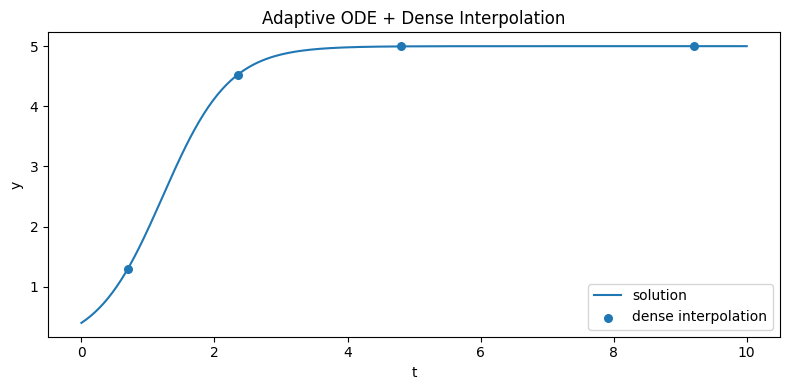

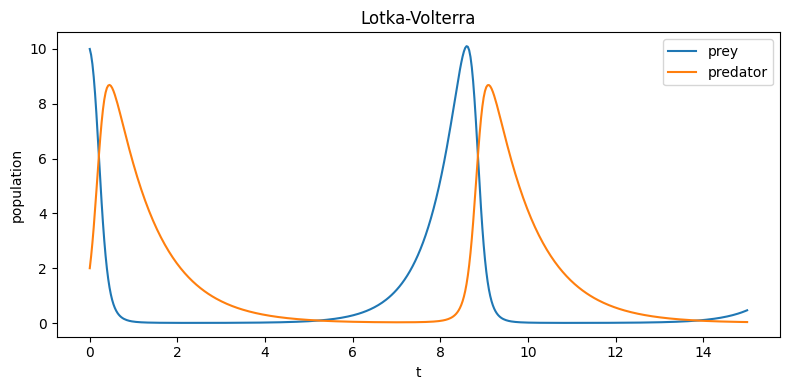

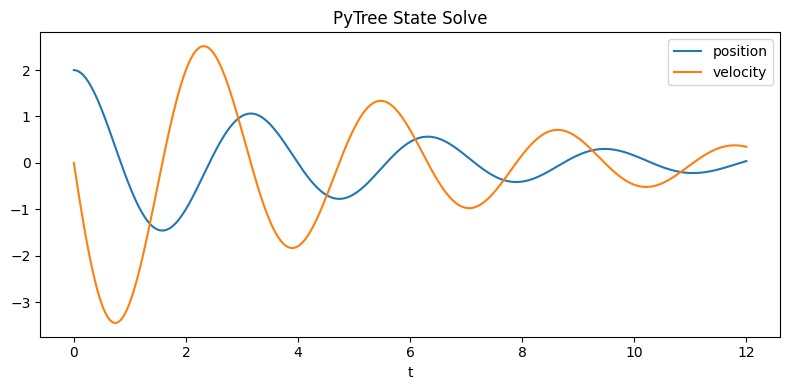

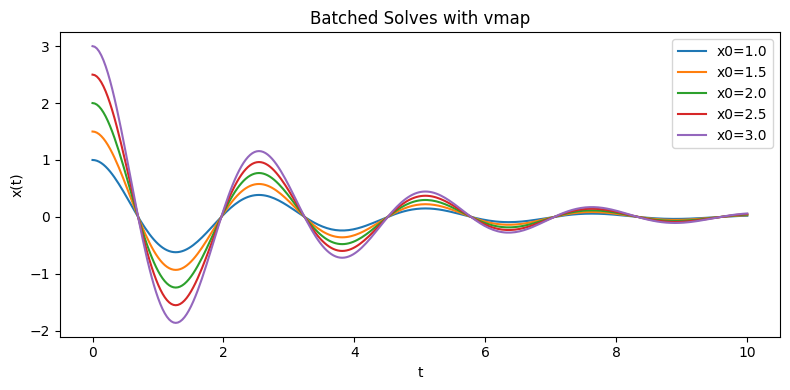

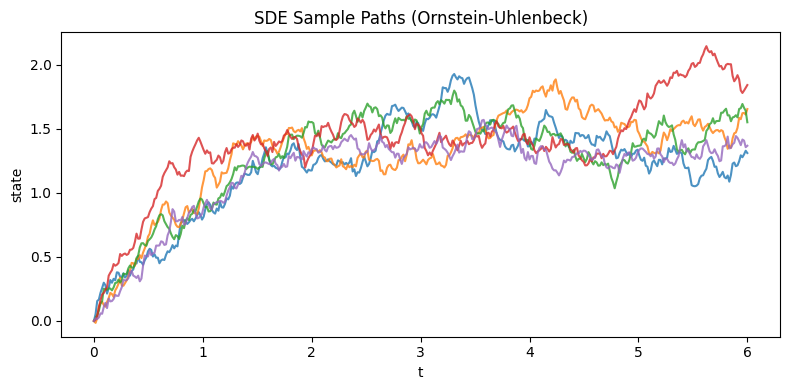

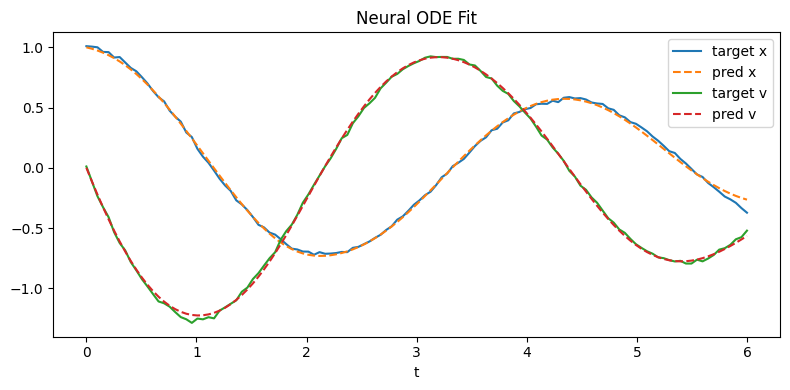

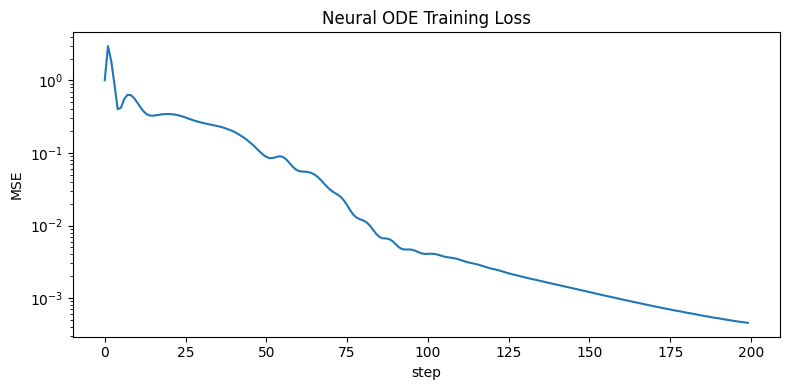


=== SUMMARY ===
1. Adaptive ODE solve with Tsit5
2. Dense interpolation using solution.evaluate
3. PyTree-valued states
4. Batched solves using jax.vmap
5. SDE simulation with VirtualBrownianTree
6. Neural ODE training with Equinox + Optax
7. JIT-compiled solve benchmark complete


In [1]:
plt.figure(figsize=(8, 4))
plt.plot(ts, sol_logistic.ys, label="solution")
plt.scatter(np.array(query_ts), np.array(query_ys), s=30, label="dense interpolation")
plt.title("Adaptive ODE + Dense Interpolation")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lv_ts, sol_lv.ys[:, 0], label="prey")
plt.plot(lv_ts, sol_lv.ys[:, 1], label="predator")
plt.title("Lotka-Volterra")
plt.xlabel("t")
plt.ylabel("population")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(pytree_ts, sol_pytree.ys["x"][:, 0], label="position")
plt.plot(pytree_ts, sol_pytree.ys["v"][:, 0], label="velocity")
plt.title("PyTree State Solve")
plt.xlabel("t")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
for i in range(batched_ys.shape[0]):
    plt.plot(batch_ts, batched_ys[i, :, 0], label=f"x0={float(batch_y0[i,0]):.1f}")
plt.title("Batched Solves with vmap")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
for i in range(sde_paths.shape[0]):
    plt.plot(sde_ts, sde_paths[i], alpha=0.8)
plt.title("SDE Sample Paths (Ornstein-Uhlenbeck)")
plt.xlabel("t")
plt.ylabel("state")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_ts, train_y[:, 0], label="target x")
plt.plot(train_ts, pred_y[:, 0], "--", label="pred x")
plt.plot(train_ts, train_y[:, 1], label="target v")
plt.plot(train_ts, pred_y[:, 1], "--", label="pred v")
plt.title("Neural ODE Fit")
plt.xlabel("t")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.yscale("log")
plt.title("Neural ODE Training Loss")
plt.xlabel("step")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

print("\n=== SUMMARY ===")
print("1. Adaptive ODE solve with Tsit5")
print("2. Dense interpolation using solution.evaluate")
print("3. PyTree-valued states")
print("4. Batched solves using jax.vmap")
print("5. SDE simulation with VirtualBrownianTree")
print("6. Neural ODE training with Equinox + Optax")
print("7. JIT-compiled solve benchmark complete")